# Phase 3 — Analyse de puissance

La phase 2 a trouvé des effets significatifs. Deux questions restent :
1. **Qu'est-ce que cette expérience était capable de détecter ?** Un résultat non significatif (par exemple les sous-groupes de la phase 2) ne veut rien dire si l'expérience n'avait aucune chance de voir l'effet.
2. **Comment dimensionner la prochaine campagne ?** Combien de clients faut-il pour détecter un effet d'une taille donnée ?

**Les quatre grandeurs liées** (fixer trois d'entre elles détermine la quatrième) :
- **α** (risque de première espèce) : probabilité de déclarer un effet alors qu'il n'y en a pas. On prend la convention 5 %, en bilatéral.
- **Puissance** = 1 − β : probabilité de détecter un effet **qui existe vraiment**. Convention : 80 %.
- **n** : taille de chaque groupe.
- **δ** : la taille de l'effet réel.

**MDE** (*Minimum Detectable Effect*) : le plus petit effet réel qu'on a 80 % de chances de détecter à α = 5 %, avec le n disponible.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats, optimize
import matplotlib.pyplot as plt

df = pd.read_csv("../data/hillstrom.csv")
controle = df[df["segment"] == "No E-Mail"]
N_PAR_GROUPE = len(controle)

ALPHA, PUISSANCE = 0.05, 0.80
z_alpha = stats.norm.ppf(1 - ALPHA / 2)   # 1,96 : seuil de rejet bilatéral
z_beta = stats.norm.ppf(PUISSANCE)        # 0,84 : marge pour atteindre 80 % de puissance

METRIQUES = ["visit", "conversion", "spend"]
COULEURS = {"visit": "#2a78d6", "conversion": "#eb6834", "spend": "#1baf7a"}
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e6e5e1", "grid.linewidth": 0.8, "axes.axisbelow": True,
                     "font.size": 10})

def fmt_entier(x):
    return f"{x:,.0f}".replace(",", " ")

print(f"n par groupe = {N_PAR_GROUPE},  z_alpha = {z_alpha:.3f},  z_beta = {z_beta:.3f},  somme = {z_alpha + z_beta:.3f}")

n par groupe = 21306,  z_alpha = 1.960,  z_beta = 0.842,  somme = 2.802


## 1. La formule « de manuel » de la MDE

Sous $H_1$, la différence estimée $\hat\delta$ suit une loi normale centrée sur le vrai effet δ, d'écart-type $SE = \sqrt{\sigma_T^2/n_T + \sigma_C^2/n_C}$. On rejette $H_0$ si $|\hat\delta| > z_{\alpha/2} \cdot SE$.

Pour que ce soit le cas avec probabilité 80 %, le vrai effet doit être à au moins $z_{\beta}$ erreurs standard au-delà du seuil :

$$MDE = (z_{1-\alpha/2} + z_{1-\beta}) \cdot SE \approx 2{,}80 \cdot SE$$

**Le chiffre à retenir : MDE ≈ 2,8 erreurs standard.** Avec l'hypothèse usuelle de **deux groupes de même taille et de même variance σ²** (celle du contrôle) :

$$MDE = 2{,}80 \cdot \sigma \sqrt{2/n} \quad\Longleftrightarrow\quad n = \frac{2\,(z_{1-\alpha/2} + z_{1-\beta})^2 \, \sigma^2}{\delta^2}$$

- Pour une proportion, $\sigma^2 = p(1-p)$.
- Pour la dépense, σ est l'écart-type de `spend` dans le contrôle.

**Conséquence clé** : n varie comme $1/\delta^2$. Diviser par 2 l'effet à détecter **multiplie par 4** l'échantillon nécessaire.

In [2]:
def mde_simple(sigma, n):
    return (z_alpha + z_beta) * sigma * np.sqrt(2 / n)

lignes = []
for m in METRIQUES:
    base = controle[m].mean()
    sigma = np.sqrt(base * (1 - base)) if m != "spend" else controle[m].std()
    d = mde_simple(sigma, N_PAR_GROUPE)
    lignes.append({"métrique": m, "niveau contrôle": base, "écart-type σ (contrôle)": sigma,
                   "σ / moyenne": sigma / base, "MDE simple": d, "MDE simple relative": d / base})
tableau_mde = pd.DataFrame(lignes).set_index("métrique")
tableau_mde.round(4)

,niveau contrôle,écart-type σ (contrôle),σ / moyenne,MDE simple,MDE simple relative
métrique,,,,,
visit,0.1062,0.3081,2.9016,0.0084,0.0788
conversion,0.0057,0.0755,13.1772,0.0020,0.3577
spend,0.6528,11.5882,17.7518,0.3145,0.4818


In [3]:
from statsmodels.stats.power import NormalIndPower

# Vérification avec statsmodels : la taille d'effet y est exprimée en écarts-types (d de Cohen)
d_std = NormalIndPower().solve_power(effect_size=None, nobs1=N_PAR_GROUPE, alpha=ALPHA, power=PUISSANCE, ratio=1.0)
for m, ligne in tableau_mde.iterrows():
    print(f"{m:<11} MDE statsmodels = {d_std * ligne['écart-type σ (contrôle)']:.4f}   (formule : {ligne['MDE simple']:.4f})")

visit       MDE statsmodels = 0.0084   (formule : 0.0084)
conversion  MDE statsmodels = 0.0020   (formule : 0.0020)
spend       MDE statsmodels = 0.3145   (formule : 0.3145)


**Première lecture** : sur la visite, l'expérience détecterait un effet de +0,84 point (+8 % relatif). Sur la conversion il faudrait +0,20 point (+36 %), et sur la dépense +0,31 $ (+48 %).

**Pourquoi un tel écart entre métriques ?** La colonne σ / moyenne (coefficient de variation) répond : ≈ 2,9 pour la visite, ≈ 13 pour la conversion, ≈ 18 pour la dépense. **Plus l'événement est rare, plus le bruit est grand relativement au signal.** Pour la dépense, il faut ajouter la dispersion des montants (30 $ à 499 $) à la rareté de l'achat.

Mais ces chiffres reposent sur une hypothèse qu'on n'a pas vérifiée. C'est ce qu'on fait maintenant.

## 2. Vérification par simulation… qui révèle un problème

On vérifie la formule **empiriquement** : on simule des milliers d'expériences avec un effet réel connu, on applique le test, et on compte la proportion de rejets de $H_0$. Elle doit être proche de la puissance annoncée.

Exemple : la conversion, avec le taux du contrôle (0,573 %), et un vrai effet égal à la MDE simple. La puissance attendue est 80 %. On simule aussi un effet nul pour vérifier que le taux de faux positifs est bien ≈ 5 %.

In [4]:
rng = np.random.default_rng(42)
N_SIMULATIONS = 20000
p_c = tableau_mde.loc["conversion", "niveau contrôle"]

def taux_de_rejet(effet, n=N_PAR_GROUPE):
    # Nombre de conversions par groupe, tiré dans une loi binomiale (équivalent à n tirages 0/1)
    x_c = rng.binomial(n, p_c, N_SIMULATIONS)
    x_t = rng.binomial(n, p_c + effet, N_SIMULATIONS)
    p_commun = (x_c + x_t) / (2 * n)
    z = (x_t - x_c) / n / np.sqrt(p_commun * (1 - p_commun) * 2 / n)
    return (np.abs(z) > z_alpha).mean()

erreur_mc = np.sqrt(0.8 * 0.2 / N_SIMULATIONS)
effet_mde = tableau_mde.loc["conversion", "MDE simple"]
print(f"Erreur de Monte-Carlo ≈ ±{1.96 * erreur_mc:.1%}")
print(f"Effet nul                     : {taux_de_rejet(0):.1%} de rejets   (attendu : {ALPHA:.0%})")
print(f"Effet = MDE simple (+{effet_mde:.3%}) : {taux_de_rejet(effet_mde):.1%} de rejets   (attendu : {PUISSANCE:.0%})")

Erreur de Monte-Carlo ≈ ±0.6%
Effet nul                     : 5.3% de rejets   (attendu : 5%)
Effet = MDE simple (+0.205%) : 73.8% de rejets   (attendu : 80%)


**Problème** : le taux de faux positifs est bon (≈ 5 %), mais la puissance n'est que de ≈ 73-74 %, loin des 80 % annoncés. L'écart dépasse largement l'erreur de Monte-Carlo : **la formule simple surestime la puissance**.

**Le coupable : l'hypothèse « même variance dans les deux groupes ».** Pour une proportion, la variance $p(1-p)$ dépend de $p$. Si le traitement fait passer la conversion de 0,57 % à 0,78 %, la variance du groupe traité augmente **de 36 %**. Pour un événement rare, ce n'est pas un détail : la variance est quasiment proportionnelle au taux lui-même. La formule simple utilise la variance du contrôle des deux côtés, donc sous-estime le bruit réel.

## 3. La formule corrigée

**Pour une proportion**, on distingue la variance sous $H_0$ (qui fixe le seuil de rejet, avec une proportion commune $\bar p$) et la variance sous $H_1$ (qui fixe la dispersion réelle de $\hat\delta$) :

$$\text{puissance} = \Phi\left(\frac{\delta - z_{1-\alpha/2}\sqrt{2\bar p(1-\bar p)/n}}{\sqrt{[p_C(1-p_C) + p_T(1-p_T)]/n}}\right), \qquad p_T = p_C + \delta, \quad \bar p = \frac{p_C + p_T}{2}$$

(plus le terme symétrique, négligeable, pour un rejet du mauvais côté).

**Pour la dépense**, même phénomène : 99 % de zéros, donc la variance est portée par les acheteurs. Si l'e-mail multiplie le nombre d'acheteurs par $(1 + \text{lift})$ sans changer le panier (ce qu'a montré la phase 2), la variance du groupe traité est multipliée à peu près par $(1 + \text{lift})$ aussi : $\sigma_T^2 \approx \sigma_C^2 (1 + \text{lift})$. On le vérifie sur les données de la phase 2 : c'est une approximation, pas une loi exacte.

Plus de formule fermée pour la MDE : on la trouve **numériquement**, en cherchant l'effet qui donne exactement 80 % de puissance (`scipy.optimize.brentq`, une recherche de racine).

In [5]:
# Vérification de l'hypothèse σ_T² ≈ σ_C² × (1 + lift) sur la dépense
for g in ["Mens E-Mail", "Womens E-Mail"]:
    traite = df.loc[df["segment"] == g, "spend"]
    lift = traite.mean() / controle["spend"].mean() - 1
    print(f"{g:<14} lift = {lift:+.0%}   σ_T² observée = {traite.var():6.1f}   "
          f"σ_C² × (1 + lift) = {controle['spend'].var() * (1 + lift):6.1f}   (σ_C² = {controle['spend'].var():.1f})")

Mens E-Mail    lift = +118%   σ_T² observée =  315.2   σ_C² × (1 + lift) =  292.6   (σ_C² = 134.3)
Womens E-Mail  lift = +65%   σ_T² observée =  228.5   σ_C² × (1 + lift) =  221.6   (σ_C² = 134.3)


In [6]:
def puissance(metrique, delta, n, alpha=ALPHA):
    # Puissance d'un test bilatéral pour un effet absolu delta, n clients par groupe
    z = stats.norm.ppf(1 - alpha / 2)
    base = tableau_mde.loc[metrique, "niveau contrôle"]
    if metrique == "spend":
        var_c = tableau_mde.loc["spend", "écart-type σ (contrôle)"] ** 2
        se0 = np.sqrt(2 * var_c / n)
        se1 = np.sqrt((var_c + var_c * (1 + delta / base)) / n)
    else:
        p_t = base + delta
        p_bar = (base + p_t) / 2
        se0 = np.sqrt(2 * p_bar * (1 - p_bar) / n)
        se1 = np.sqrt((base * (1 - base) + p_t * (1 - p_t)) / n)
    return stats.norm.sf((z * se0 - delta) / se1) + stats.norm.cdf((-z * se0 - delta) / se1)

def mde(metrique, n, puissance_cible=PUISSANCE):
    base = tableau_mde.loc[metrique, "niveau contrôle"]
    return optimize.brentq(lambda d: puissance(metrique, d, n) - puissance_cible, 1e-9, 5 * base)

def n_necessaire(metrique, delta, puissance_cible=PUISSANCE):
    return optimize.brentq(lambda n: puissance(metrique, delta, n) - puissance_cible, 2, 1e10)

print(f"Puissance corrigée à la MDE simple (conversion) : {puissance('conversion', effet_mde, N_PAR_GROUPE):.1%}"
      f"   ← la simulation donnait ≈ 74 %")
print(f"Simulation à la MDE corrigée : {taux_de_rejet(mde('conversion', N_PAR_GROUPE)):.1%} de rejets   (attendu : 80 %)")

Puissance corrigée à la MDE simple (conversion) : 73.3%   ← la simulation donnait ≈ 74 %
Simulation à la MDE corrigée : 80.6% de rejets   (attendu : 80 %)


In [7]:
tableau_mde["MDE corrigée"] = [mde(m, N_PAR_GROUPE) for m in METRIQUES]
tableau_mde["MDE corrigée relative"] = tableau_mde["MDE corrigée"] / tableau_mde["niveau contrôle"]
tableau_mde[["niveau contrôle", "MDE simple", "MDE corrigée", "MDE simple relative", "MDE corrigée relative"]].round(4)

,niveau contrôle,MDE simple,MDE corrigée,MDE simple relative,MDE corrigée relative
métrique,,,,,
visit,0.1062,0.0084,0.0085,0.0788,0.0801
conversion,0.0057,0.0020,0.0022,0.3577,0.3908
spend,0.6528,0.3145,0.3257,0.4818,0.4989


**Lecture** : la formule corrigée est validée par simulation (≈ 80 %). Avec ≈ 21 300 clients par groupe, l'expérience pouvait détecter à 80 % :
- **visite** : +0,85 point (+8 %), la correction ne change presque rien car le taux n'est pas rare ;
- **conversion** : +0,22 point (**+39 %**, contre +36 % annoncé par la formule simple) ;
- **dépense** : +0,33 $ (**+50 %**, contre +48 %).

L'approximation $\sigma_T^2 \approx \sigma_C^2(1 + \text{lift})$ est raisonnable mais légèrement optimiste (292 contre 315 observé pour l'e-mail Hommes, 222 contre 229 pour l'e-mail Femmes) : les acheteurs « gagnés » par l'e-mail ajoutent un peu plus de dispersion que prévu.

**Leçon méthodologique** : pour les métriques rares ou zéro-inflatées, la formule de manuel est **optimiste** et conduit à sous-dimensionner les tests. L'erreur est de 6 à 7 points de puissance pour la conversion, qui aurait donc demandé ≈ 20 % de clients en plus que prévu. Une simulation rapide suffit à le détecter.

**Confrontation avec la phase 2** : l'effet de l'e-mail Femmes sur la dépense (+0,42 $) ne dépasse la MDE corrigée (0,33 $) que d'un facteur 1,3. Il était détectable, mais sans grande marge. C'est cohérent avec son IC très large ([0,17 ; 0,68]).

## 4. Puissance de l'expérience pour les effets observés

Quelle était la probabilité de détecter des effets **de la taille de ceux observés** ?

⚠️ **Mise en garde importante** : la « puissance observée » (*post-hoc power*), calculée en prenant l'effet estimé pour l'effet réel, n'apporte **aucune information nouvelle**. C'est une transformation monotone de la p-value : un résultat significatif aura toujours une puissance observée élevée, et inversement (Hoenig & Heisey, 2001). On la montre ici pour donner un ordre de grandeur, pas comme preuve. La bonne pratique est de raisonner sur des **effets plausibles fixés a priori** (section 5).

In [8]:
lignes = []
for g in ["Mens E-Mail", "Womens E-Mail"]:
    traite = df[df["segment"] == g]
    for m in METRIQUES:
        effet = traite[m].mean() - controle[m].mean()
        lignes.append({"traitement": g, "métrique": m, "effet observé": effet,
                       "effet / MDE corrigée": effet / tableau_mde.loc[m, "MDE corrigée"],
                       "puissance « observée »": puissance(m, effet, N_PAR_GROUPE)})
pd.DataFrame(lignes).set_index(["traitement", "métrique"]).round(3)

effet observé  effet / MDE corrigée  \
traitement    métrique                                          
Mens E-Mail   visit               0.077                 9.003   
              conversion          0.007                 3.041   
              spend               0.770                 2.364   
Womens E-Mail visit               0.045                 5.317   
              conversion          0.003                 1.390   
              spend               0.424                 1.303   

                          puissance « observée »  
traitement    métrique                            
Mens E-Mail   visit                        1.000  
              conversion                   1.000  
              spend                        1.000  
Womens E-Mail visit                        1.000  
              conversion                   0.965  
              spend                        0.943

## 5. Courbes de puissance

Pour des effets **fixés a priori** (en lift relatif par rapport au contrôle), quelle puissance avait l'expérience ? Chaque courbe montre la probabilité de détection en fonction de l'effet réel (formule corrigée).

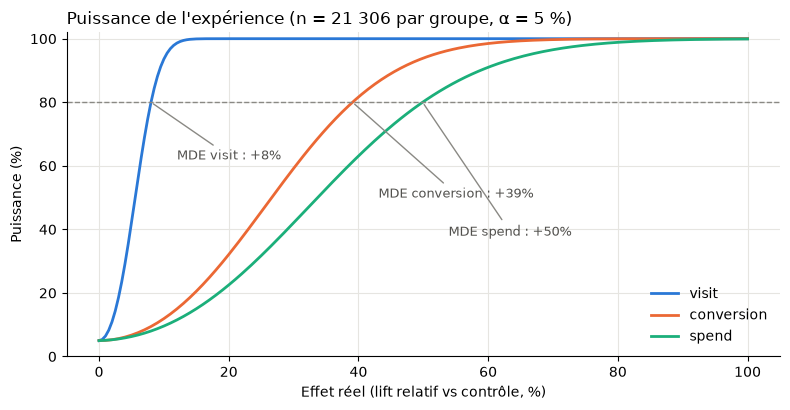

In [9]:
lifts = np.linspace(0, 1.0, 201)
fig, ax = plt.subplots(figsize=(8, 4.2))
for i, (m, ligne) in enumerate(tableau_mde.iterrows()):
    courbe = [puissance(m, l * ligne["niveau contrôle"], N_PAR_GROUPE) for l in lifts]
    ax.plot(lifts * 100, np.array(courbe) * 100, color=COULEURS[m], linewidth=2, label=m)
    x_mde = ligne["MDE corrigée relative"] * 100
    ax.annotate(f"MDE {m} : +{ligne['MDE corrigée relative']:.0%}", xy=(x_mde, 80),
                xytext=(x_mde + 4, 62 - 12 * i), fontsize=9, color="#52514e",
                arrowprops={"arrowstyle": "-", "color": "#8a8984"})
ax.axhline(80, color="#8a8984", linewidth=1, linestyle="--")
ax.set_xlabel("Effet réel (lift relatif vs contrôle, %)")
ax.set_ylabel("Puissance (%)")
ax.set_ylim(0, 102)
ax.set_title(f"Puissance de l'expérience (n = {fmt_entier(N_PAR_GROUPE)} par groupe, α = 5 %)", loc="left")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.savefig("../docs/figures/03_courbes_puissance.png", dpi=150)
plt.show()

## 6. Dimensionner une prochaine campagne

Combien de clients **par groupe** faut-il pour détecter un lift relatif donné ? La relation en $1/\delta^2$ appelle une échelle logarithmique.

In [10]:
lifts_cibles = [0.05, 0.10, 0.20, 0.30, 0.50]
tableau_n = pd.DataFrame({
    f"+{l:.0%}": {m: n_necessaire(m, l * tableau_mde.loc[m, "niveau contrôle"]) for m in METRIQUES}
    for l in lifts_cibles
})
tableau_n.map(fmt_entier)

,+5%,+10%,+20%,+30%,+50%
visit,54 024,13 793,3 590,1 657,640
conversion,1 117 392,286 119,74 914,34 798,13 608
spend,1 993 506,502 044,127 322,57 380,21 215


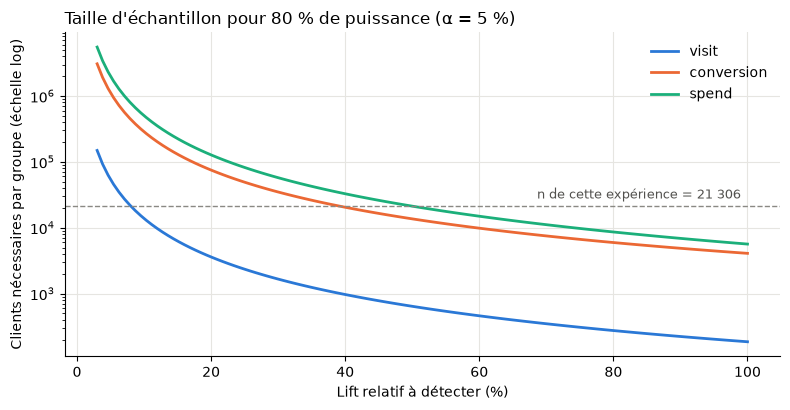

In [11]:
lifts_courbe = np.linspace(0.03, 1.0, 120)
fig, ax = plt.subplots(figsize=(8, 4.2))
for m, ligne in tableau_mde.iterrows():
    ax.plot(lifts_courbe * 100, [n_necessaire(m, l * ligne["niveau contrôle"]) for l in lifts_courbe],
            color=COULEURS[m], linewidth=2, label=m)
ax.axhline(N_PAR_GROUPE, color="#8a8984", linewidth=1, linestyle="--")
ax.text(99, N_PAR_GROUPE * 1.3, f"n de cette expérience = {fmt_entier(N_PAR_GROUPE)}", ha="right", fontsize=9, color="#52514e")
ax.set_yscale("log")
ax.set_xlabel("Lift relatif à détecter (%)")
ax.set_ylabel("Clients nécessaires par groupe (échelle log)")
ax.set_title("Taille d'échantillon pour 80 % de puissance (α = 5 %)", loc="left")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("../docs/figures/03_taille_echantillon.png", dpi=150)
plt.show()

**Lecture** : détecter un lift de +10 % demande ≈ 14 000 clients par groupe pour la visite, mais ≈ 290 000 pour la conversion et ≈ 500 000 pour la dépense. **Le choix de la métrique principale d'un test conditionne son coût d'un facteur 20 à 35.** D'où une pratique courante : piloter les tests sur une métrique sensible et précoce (la visite, *proxy*), et ne valider la métrique business (la dépense) que sur des effets importants ou des tests plus longs.

## 7. La puissance des analyses en sous-groupes

En phase 2, l'interaction « e-mail Femmes × client achetant pour hommes » valait −0,38 $ avec p = 0,14. Faut-il conclure qu'il n'y a pas d'hétérogénéité ? La puissance donne la réponse.

**Pourquoi les interactions coûtent cher** : une interaction est une **différence de différences**. Elle combine 4 moyennes de sous-groupes, chacun de taille ≈ n/2, et sa variance est donc ≈ **4 fois** celle de l'effet principal. Pour détecter une interaction de la même taille que l'effet principal, il faut ≈ 4 fois plus de clients. Et les interactions réelles sont généralement plus petites que les effets principaux (Gelman, 2018 : *« You need 16 times the sample size to estimate an interaction than to estimate a main effect »*).

Ici on part directement de l'erreur standard estimée de l'interaction (régression avec erreurs robustes), sans avoir besoin de la formule par métrique.

In [12]:
import statsmodels.formula.api as smf

modele = smf.ols("spend ~ C(segment, Treatment('No E-Mail')) * mens", df).fit(cov_type="HC1")
terme = "C(segment, Treatment('No E-Mail'))[T.Womens E-Mail]:mens"
interaction, se_interaction = modele.params[terme], modele.bse[terme]

mde_interaction = (z_alpha + z_beta) * se_interaction
puissance_interaction = stats.norm.sf(z_alpha - abs(interaction) / se_interaction)
facteur = (mde_interaction / abs(interaction)) ** 2
print(f"Interaction estimée          : {interaction:+.3f} $  (erreur std {se_interaction:.3f})")
print(f"MDE de l'interaction         : {mde_interaction:.3f} $")
print(f"Puissance pour {abs(interaction):.2f} $         : {puissance_interaction:.0%}")
print(f"Échantillon pour 80 %        : ×{facteur:.1f} soit ≈ {fmt_entier(facteur * len(df))} clients au total")

Interaction estimée          : -0.375 $  (erreur std 0.257)
MDE de l'interaction         : 0.719 $
Puissance pour 0.38 $         : 31%
Échantillon pour 80 %        : ×3.7 soit ≈ 234 828 clients au total


**Lecture** : pour détecter une interaction de −0,38 $, l'expérience n'avait qu'**environ 30 % de puissance**. Il aurait fallu ≈ 3,7 fois plus de clients (≈ 235 000) pour atteindre 80 %. Le « non significatif » de la phase 2 est donc **non concluant**, pas une preuve d'absence d'hétérogénéité.

**Conséquences pour la phase 4 (uplift)** :
- Les effets individuels sont **petits face au bruit** : on ne pourra pas « voir » l'uplift d'un client, seulement l'estimer en moyenne sur des groupes de clients qui se ressemblent. Les modèles d'uplift seront donc **bruités**, et il faudra les évaluer sur un **jeu de test** séparé avec des métriques adaptées (courbes d'uplift / Qini), jamais sur l'échantillon d'entraînement.
- Modéliser l'uplift de la **dépense** directement sera le plus difficile (MDE relative ≈ 50 %, et le moindre gros achat isolé pèse lourd). La **conversion** porte mieux le signal, et la **visite** encore mieux. Comme la phase 2 a montré que l'effet sur la dépense passe par la conversion, c'est un bon compromis.

## Conclusion de la phase 3

| Métrique | Niveau contrôle | MDE corrigée (80 %, α = 5 %) | MDE relative | n / groupe pour +10 % |
|---|---|---|---|---|
| Visite | 10,62 % | +0,85 pt | +8 % | ≈ 14 000 |
| Conversion | 0,573 % | +0,22 pt | +39 % | ≈ 290 000 |
| Dépense | 0,653 $ | +0,33 $ | +50 % | ≈ 500 000 |

1. **MDE ≈ 2,8 erreurs standard**, et n varie en $1/\delta^2$.
2. **La formule de manuel (variances égales) est optimiste** pour les métriques rares : 74 % de puissance réelle au lieu de 80 % pour la conversion. On l'a détecté **par simulation**, puis corrigé (variance sous $H_1$ ; pour la dépense, $\sigma_T^2 \approx \sigma_C^2(1 + \text{lift})$, approximation vérifiée sur les données).
3. L'expérience était **très puissante pour la visite**, **correcte pour la conversion**, et **juste suffisante pour la dépense** : l'effet de l'e-mail Femmes sur la dépense ne dépassait la MDE que d'un facteur 1,3.
4. Les **analyses en sous-groupes** sont très peu puissantes (≈ 30 % pour l'interaction de la phase 2) : l'absence de significativité n'y prouve rien.
5. Pour une prochaine campagne : piloter sur la visite (sensible), et réserver la dépense à des effets ≥ +50 % ou à des échantillons beaucoup plus grands.